# Principal Component Analysis with Cancer Data

In [45]:
#Import all the necessary modules
#Import all the necessary modules
import pandas as pd
import numpy as np
import os
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Q1. Load the Data file into Python DataFrame and view top 10 rows

In [46]:
# Loaded the data from the file
cancer_data = pd.read_csv("cancer.csv")

In [47]:
# displaying the top 10 rows
cancer_data.head(10)

,ID,ClumpThickness,Cell Size,Cell Shape,Marginal Adhesion,Single Epithelial Cell Size,Bare Nuclei,Normal Nucleoli,Bland Chromatin,Mitoses,Class
0,1000025,5,1,1,1,2,1,3,1,1,2
1,1002945,5,4,4,5,7,10,3,2,1,2
2,1015425,3,1,1,1,2,2,3,1,1,2
3,1016277,6,8,8,1,3,4,3,7,1,2
4,1017023,4,1,1,3,2,1,3,1,1,2
5,1017122,8,10,10,8,7,10,9,7,1,4
6,1018099,1,1,1,1,2,10,3,1,1,2
7,1018561,2,1,2,1,2,1,3,1,1,2
8,1033078,2,1,1,1,2,1,1,1,5,2
9,1033078,4,2,1,1,2,1,2,1,1,2


# Q2 Print the datatypes of each column and the shape of the dataset. Perform descriptive analysis 

In [48]:
# displaying the datatypes of each column
cancer_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 699 entries, 0 to 698
Data columns (total 11 columns):
ID                             699 non-null int64
ClumpThickness                 699 non-null int64
Cell Size                      699 non-null int64
Cell Shape                     699 non-null int64
Marginal Adhesion              699 non-null int64
Single Epithelial Cell Size    699 non-null int64
Bare Nuclei                    699 non-null object
Normal Nucleoli                699 non-null int64
Bland Chromatin                699 non-null int64
Mitoses                        699 non-null int64
Class                          699 non-null int64
dtypes: int64(10), object(1)
memory usage: 60.1+ KB


In [49]:
# displaying the shape of the data set
cancer_data.shape

(699, 11)

In [6]:
# The data set consists of 699 rows and 11 columns
# Bare Nuclei column is of object datatype
# All other columns are of integer datatype
# Class column is the target variable

# Q3 Check for missing value check, incorrect data, duplicate data and perform imputation with mean, median, mode as necessary.


In [50]:
# Getting count of rows having ?
# cancer_data.eq(r'?').any(1).sum()

cancer_data['Bare Nuclei'].value_counts()[['?']].sum()
# There are 16 rows having ? 

16

In [51]:
# 16 values are corrupted. We can either delete them as it forms roughly 2% of data.
# Here we would like to impute it with suitable values
# imputing with mean value
cancer_data.replace('?','0',inplace=True)
cancer_data['Bare Nuclei']=cancer_data['Bare Nuclei'].astype(str).astype(int)
cancer_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 699 entries, 0 to 698
Data columns (total 11 columns):
ID                             699 non-null int64
ClumpThickness                 699 non-null int64
Cell Size                      699 non-null int64
Cell Shape                     699 non-null int64
Marginal Adhesion              699 non-null int64
Single Epithelial Cell Size    699 non-null int64
Bare Nuclei                    699 non-null int32
Normal Nucleoli                699 non-null int64
Bland Chromatin                699 non-null int64
Mitoses                        699 non-null int64
Class                          699 non-null int64
dtypes: int32(1), int64(10)
memory usage: 57.4 KB


# Q4. Perform bi variate analysis including correlation & pairplots. 


In [52]:
# Check for correlation of variable
cancer_data.corr(method ='pearson') 


,ID,ClumpThickness,Cell Size,Cell Shape,Marginal Adhesion,Single Epithelial Cell Size,Bare Nuclei,Normal Nucleoli,Bland Chromatin,Mitoses,Class
ID,1.000000,-0.055308,-0.041603,-0.041576,-0.064878,-0.045528,-0.089871,-0.060051,-0.052072,-0.034901,-0.080226
ClumpThickness,-0.055308,1.000000,0.644913,0.654589,0.486356,0.521816,0.589296,0.558428,0.535835,0.350034,0.716001
Cell Size,-0.041603,0.644913,1.000000,0.906882,0.705582,0.751799,0.684569,0.755721,0.722865,0.458693,0.817904
Cell Shape,-0.041576,0.654589,0.906882,1.000000,0.683079,0.719668,0.704529,0.735948,0.719446,0.438911,0.818934
Marginal Adhesion,-0.064878,0.486356,0.705582,0.683079,1.000000,0.599599,0.665723,0.666715,0.603352,0.417633,0.696800
Single Epithelial Cell Size,-0.045528,0.521816,0.751799,0.719668,0.599599,1.000000,0.582904,0.616102,0.628881,0.479101,0.682785
Bare Nuclei,-0.089871,0.589296,0.684569,0.704529,0.665723,0.582904,1.000000,0.671545,0.572054,0.342795,0.817653
Normal Nucleoli,-0.060051,0.558428,0.755721,0.735948,0.666715,0.616102,0.671545,1.000000,0.665878,0.344169,0.756616
Bland Chromatin,-0.052072,0.535835,0.722865,0.719446,0.603352,0.628881,0.572054,0.665878,1.000000,0.428336,0.712244
Mitoses,-0.034901,0.350034,0.458693,0.438911,0.417633,0.479101,0.342795,0.344169,0.428336,1.000000,0.423170


In [0]:
# Cell size shows high significance with cell shape,marginal adhesion, single epithelial cell size,bare nuclei, normal nucleoli 
# and bland chromatin
# Target variable shows high correlation with most of these variables

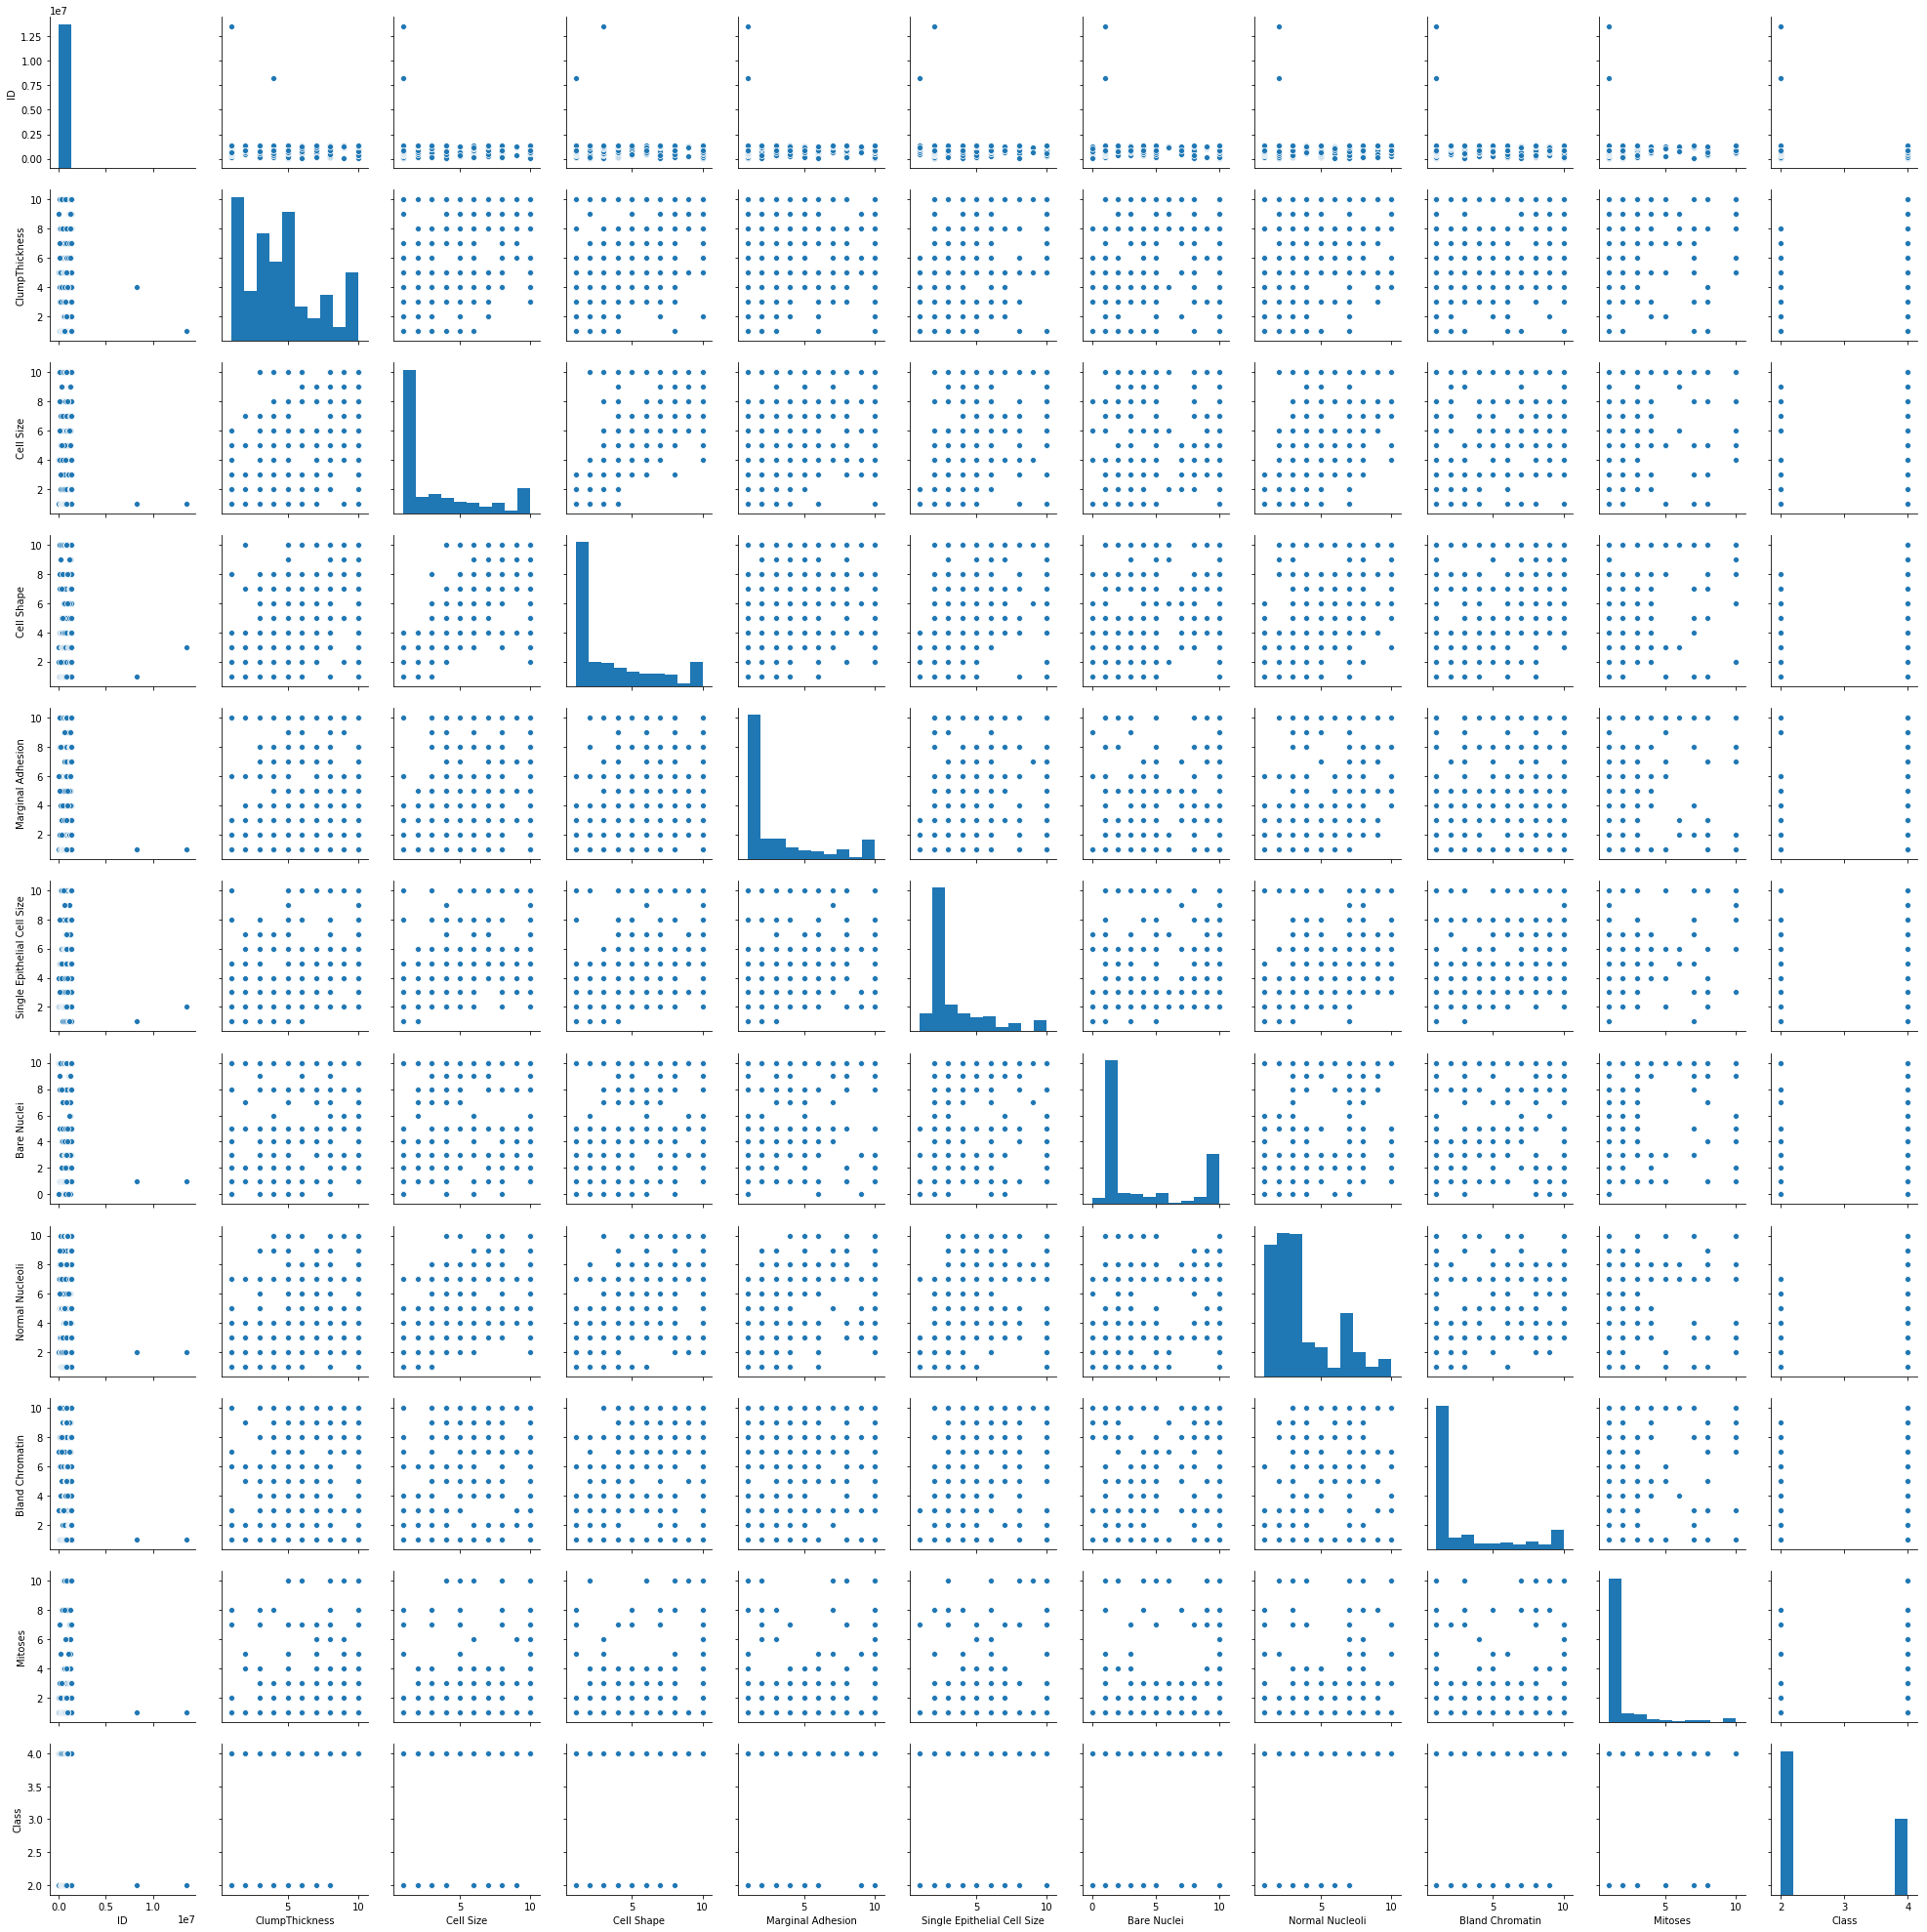

In [53]:
#Let us check for pair plots
import seaborn as sns
sns.pairplot(cancer_data)

# Q5 Remove any unwanted columns or outliers, standardize variables in this pre-processing step

In [54]:
# removing id column since it is not needed for analysis

cancer_data = cancer_data.drop('ID', axis=1)


In [55]:
cancer_data

,ClumpThickness,Cell Size,Cell Shape,Marginal Adhesion,Single Epithelial Cell Size,Bare Nuclei,Normal Nucleoli,Bland Chromatin,Mitoses,Class
0,5,1,1,1,2,1,3,1,1,2
1,5,4,4,5,7,10,3,2,1,2
2,3,1,1,1,2,2,3,1,1,2
3,6,8,8,1,3,4,3,7,1,2
4,4,1,1,3,2,1,3,1,1,2
5,8,10,10,8,7,10,9,7,1,4
6,1,1,1,1,2,10,3,1,1,2
7,2,1,2,1,2,1,3,1,1,2
8,2,1,1,1,2,1,1,1,5,2
9,4,2,1,1,2,1,2,1,1,2


In [56]:
# Split the wine data into separate training (70%) and test (30%) sets 
# Define features
X = cancer_data.iloc[:,0:9]

# Define categorical outcome 
y = cancer_data.iloc[:,9]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=.3, 
                                                    stratify=y, 
                                                    random_state=42)

In [57]:
# Standardize feature space to have mean 0 and variance 1
sc = StandardScaler()
X_std =  sc.fit_transform(X) 

C:\Anaconda\lib\site-packages\sklearn\preprocessing\data.py:625: DataConversionWarning: Data with input dtype int32, int64 were all converted to float64 by StandardScaler.
  return self.partial_fit(X, y)
C:\Anaconda\lib\site-packages\sklearn\base.py:462: DataConversionWarning: Data with input dtype int32, int64 were all converted to float64 by StandardScaler.
  return self.fit(X, **fit_params).transform(X)


# Q6 Create a covariance matrix for identifying Principal components

In [0]:
# PCA
# Step 1 - Create covariance matrix


In [58]:
cov_matrix = np.cov(X_std.T)
print('Covariance Matrix \n%s', cov_matrix)

Covariance Matrix 
%s [[1.00143266 0.64583645 0.65552689 0.48705303 0.52256381 0.59014075
  0.5592282  0.53660222 0.35053534]
 [0.64583645 1.00143266 0.90818117 0.70659267 0.75287621 0.68554968
  0.75680368 0.72390044 0.4593503 ]
 [0.65552689 0.90818117 1.00143266 0.68405782 0.72069948 0.70553814
  0.73700282 0.72047704 0.43953974]
 [0.48705303 0.70659267 0.68405782 1.00143266 0.60045809 0.66667705
  0.66767051 0.60421681 0.41823111]
 [0.52256381 0.75287621 0.72069948 0.60045809 1.00143266 0.58373939
  0.61698451 0.62978166 0.47978787]
 [0.59014075 0.68554968 0.70553814 0.66667705 0.58373939 1.00143266
  0.6725067  0.57287403 0.34328587]
 [0.5592282  0.75680368 0.73700282 0.66767051 0.61698451 0.6725067
  1.00143266 0.66683179 0.34466258]
 [0.53660222 0.72390044 0.72047704 0.60421681 0.62978166 0.57287403
  0.66683179 1.00143266 0.42894941]
 [0.35053534 0.4593503  0.43953974 0.41823111 0.47978787 0.34328587
  0.34466258 0.42894941 1.00143266]]


# Q7 Identify eigen values and eigen vector

In [0]:
# Step 2- Get eigen values and eigen vector

In [59]:
eigenvalues, eigenvectors = np.linalg.eig(cov_matrix)
print('Eigen Vectors \n%s', eigenvectors)
print('\n Eigen Values \n%s', eigenvalues)

Eigen Vectors 
%s [[-0.30292446 -0.14728724  0.00171985 -0.86193801 -0.07974264  0.07647456
  -0.24290868  0.26773717  0.02660985]
 [-0.38127363 -0.04994886  0.73632898  0.0207124   0.20267222 -0.13753297
   0.4391189   0.12149144 -0.20481512]
 [-0.37760282 -0.08532737 -0.66500091 -0.03317637  0.176675   -0.10499726
   0.58493756  0.05060655 -0.14091492]
 [-0.33292274 -0.04501348 -0.04612047  0.41972041 -0.46800847  0.04604803
  -0.12290104  0.67131862  0.14804802]
 [-0.33653384  0.1633891  -0.06807047  0.11175896  0.36301869 -0.68838416
  -0.45009176 -0.05203136  0.17882994]
 [-0.33285064 -0.24637458  0.07092611 -0.00913366 -0.55271696 -0.13055944
   0.10967743 -0.60469376  0.3509567 ]
 [-0.34597842 -0.22997335 -0.05811865  0.19829425 -0.0033783   0.25734531
  -0.41000684 -0.25652337 -0.69610698]
 [-0.33586575  0.02525521  0.01901354  0.13438809  0.45696771  0.62219668
  -0.07981509 -0.09793341  0.50618683]
 [-0.22998763  0.90861576 -0.00774395 -0.09702428 -0.23708563  0.13348277
   0

# Q8 Find variance and cumulative variance by each eigen vector

In [73]:
tot = sum(eigenvalues)
var_explained = [(i / tot) for i in sorted(eigenvalues, reverse=True)]  # an array of variance explained by each 
# eigen vector... there will be 9 entries as there are 9 eigen vectors)


In [74]:
cum_var_exp = np.cumsum(var_explained)  # an array of cumulative variance. There will be 9 entries with 8 th entry 
# cumulative reaching almost 100%

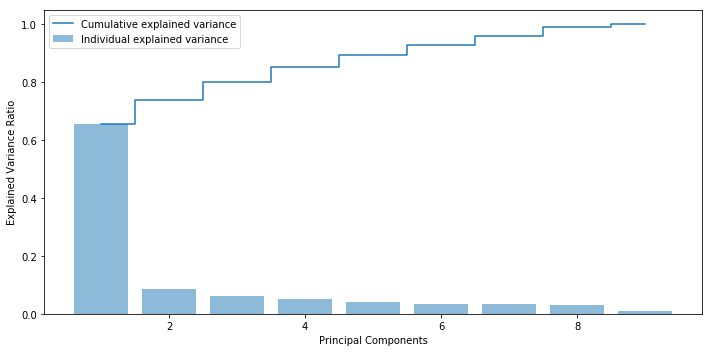

In [77]:
# Ploting 
plt.figure(figsize=(10 , 5))
plt.bar(range(1, eigenvalues.size + 1), var_explained, alpha = 0.5, align = 'center', label = 'Individual explained variance')
plt.step(range(1, eigenvalues.size + 1), cum_var_exp, where='mid', label = 'Cumulative explained variance')
plt.ylabel('Explained Variance Ratio')
plt.xlabel('Principal Components')
plt.legend(loc = 'best')
plt.tight_layout()
plt.show()

# Q9 Use PCA command from sklearn and find Principal Components. Transform data to components formed

In [62]:
from sklearn.decomposition import PCA

In [63]:
X_centered = X - X.mean(axis=0)

In [64]:
pca = PCA(n_components=2)
pca.fit(X_centered) # create eigen vectors and eigen values

PCA(copy=True, iterated_power='auto', n_components=2, random_state=None,
  svd_solver='auto', tol=0.0, whiten=False)

In [65]:
X_pca = pca.transform(X_centered) # transform the original datapoints into PCA data points/ will plot the eigen vector and eigen values

In [66]:
X_pca.shape

(699, 2)